# Modélisation de la fréquence et de la sévérité

Ce notebook décompose le risque d’assurance en deux composantes :

- la fréquence : nombre attendu de sinistres ;
- la sévérité : coût moyen attendu des sinistres.

Cette approche permet de calculer un coût attendu pour chaque contrat et de produire un score de risque utile à la construction des groupes collaboratifs.

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib

from pathlib import Path

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_tweedie_deviance
)
from sklearn.linear_model import TweedieRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import (
    PoissonRegressor,
    GammaRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_poisson_deviance,
    mean_gamma_deviance
)

In [2]:
data_path = Path(
    "../data/processed/cleaned_data.csv"
)

df = pd.read_csv(data_path)

In [3]:
print(f"Dimensions : {df.shape}")
print(f"Années : {sorted(df['year'].unique())}")

Dimensions : (122935, 26)
Années : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [4]:
numerical_features = [
    "Age_client",
    "age_of_car_M",
    "Car_power_M",
    "Insuredcapital_content_re",
    "Insuredcapital_continent_re",
    "Client_Seniority"
]

binary_features = [
    "gender",
    "Car_2ndDriver_M",
    "num_policiesC",
    "metro_code",
    "Policy_PaymentMethodA",
    "Policy_PaymentMethodH",
    "appartment"
]

feature_columns = (
    numerical_features
    + binary_features
)

In [5]:
frequency_target = "Total_NClaims"
severity_target = "Average_Claim_Severity"
total_cost_target = "Total_Claims"

In [6]:
train_mask = df["year"].isin([1, 2, 3])
validation_mask = df["year"] == 4
test_mask = df["year"] == 5

In [7]:
X_train_frequency = df.loc[
    train_mask,
    feature_columns
].copy()

y_train_frequency = df.loc[
    train_mask,
    frequency_target
].copy()

X_validation_frequency = df.loc[
    validation_mask,
    feature_columns
].copy()

y_validation_frequency = df.loc[
    validation_mask,
    frequency_target
].copy()

X_test_frequency = df.loc[
    test_mask,
    feature_columns
].copy()

y_test_frequency = df.loc[
    test_mask,
    frequency_target
].copy()

In [8]:
frequency_summary = pd.DataFrame({
    "Ensemble": [
        "Entraînement",
        "Validation",
        "Test"
    ],
    "Observations": [
        len(y_train_frequency),
        len(y_validation_frequency),
        len(y_test_frequency)
    ],
    "Frequence_moyenne": [
        y_train_frequency.mean(),
        y_validation_frequency.mean(),
        y_test_frequency.mean()
    ],
    "Pourcentage_zero": [
        (y_train_frequency == 0).mean() * 100,
        (y_validation_frequency == 0).mean() * 100,
        (y_test_frequency == 0).mean() * 100
    ]
})

frequency_summary.round(4)

,Ensemble,Observations,Frequence_moyenne,Pourcentage_zero
0,Entraînement,92607,0.0667,94.2056
1,Validation,17044,0.0576,94.9308
2,Test,13284,0.0529,95.3327


In [9]:
assert (y_train_frequency >= 0).all()
assert (y_validation_frequency >= 0).all()
assert (y_test_frequency >= 0).all()

print("La cible de fréquence est valide.")

La cible de fréquence est valide.


In [11]:
def evaluate_frequency_model(
    model_name,
    y_true,
    predictions
):
    safe_predictions = np.clip(
        predictions,
        1e-10,
        None
    )

    return {
        "Modele": model_name,
        "MAE": mean_absolute_error(
            y_true,
            predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                predictions
            )
        ),
        "Poisson_deviance": (
            mean_poisson_deviance(
                y_true,
                safe_predictions
            )
        ),
        "Frequence_reelle": y_true.mean(),
        "Frequence_predite": predictions.mean()
    }

In [12]:
dummy_frequency_model = DummyRegressor(
    strategy="mean"
)

In [13]:
dummy_frequency_model.fit(
    X_train_frequency,
    y_train_frequency
)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None
Name,Type,Value
"constant_ constant_: ndarray of shape (1, n_outputs)Mean or median or quantile of the training targets or constant valuegiven by the user.","ndarray[float64](1, 1)",[[0.07]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](13,)","['Age_client','age_of_car_M','Car_power_M',...,'Policy_PaymentMethodA', 'Policy_PaymentMethodH','appartment']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,13
n_outputs_ n_outputs_: intNumber of outputs.,int,1


In [14]:
dummy_frequency_predictions = (
    dummy_frequency_model.predict(
        X_validation_frequency
    )
)

In [15]:
dummy_frequency_results = (
    evaluate_frequency_model(
        model_name="Dummy fréquence",
        y_true=y_validation_frequency,
        predictions=(
            dummy_frequency_predictions
        )
    )
)

pd.DataFrame([
    dummy_frequency_results
]).round(5)

,Modele,MAE,RMSE,Poisson_deviance,Frequence_reelle,Frequence_predite
0,Dummy fréquence,0.11752,0.2641,0.3501,0.05762,0.06666


In [16]:
frequency_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [17]:
poisson_model = PoissonRegressor(
    alpha=1.0,
    max_iter=1000
)

In [18]:
poisson_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            frequency_preprocessor
        ),
        (
            "model",
            poisson_model
        )
    ]
)

In [19]:
poisson_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            frequency_preprocessor
        ),
        (
            "model",
            poisson_model
        )
    ]
)

In [20]:
poisson_pipeline.fit(
    X_train_frequency,
    y_train_frequency
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age_client','age_of_car_M','Car_power_M',...,'Policy_PaymentMethodA', 'Policy_PaymentMethodH','appartment']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('binary', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_featu

In [22]:
poisson_validation_predictions = (
    poisson_pipeline.predict(
        X_validation_frequency
    )
)

In [23]:
print(
    "Prédiction minimale :",
    poisson_validation_predictions.min()
)

print(
    "Prédiction maximale :",
    poisson_validation_predictions.max()
)

Prédiction minimale : 0.06308449236268712
Prédiction maximale : 0.06932920792226772


In [26]:
assert (
    poisson_validation_predictions > 0
).all()

print("Toutes les fréquences prédites sont positives.")

Toutes les fréquences prédites sont positives.


In [29]:
poisson_results = evaluate_frequency_model(
    model_name="Régression de Poisson",
    y_true=y_validation_frequency,
    predictions=(
        poisson_validation_predictions
    )
)

In [30]:
frequency_model_comparison = pd.DataFrame([
    dummy_frequency_results,
    poisson_results
])

frequency_model_comparison.round(5)

,Modele,MAE,RMSE,Poisson_deviance,Frequence_reelle,Frequence_predite
0,Dummy fréquence,0.11752,0.26410,0.35010,0.05762,0.06666
1,Régression de Poisson,0.11737,0.26404,0.34959,0.05762,0.06653


In [31]:
frequency_comparison_plot = pd.DataFrame({
    "Valeur": [
        y_validation_frequency.mean(),
        poisson_validation_predictions.mean()
    ],
    "Type": [
        "Fréquence réelle",
        "Fréquence prédite"
    ]
})

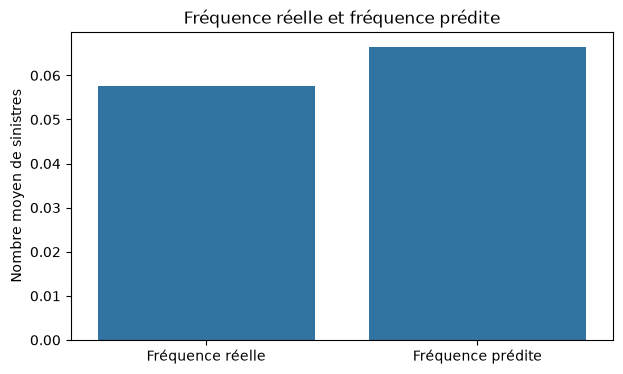

In [32]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=frequency_comparison_plot,
    x="Type",
    y="Valeur"
)

plt.title(
    "Fréquence réelle et fréquence prédite"
)
plt.ylabel("Nombre moyen de sinistres")
plt.xlabel("")
plt.show()

In [33]:
frequency_validation_analysis = pd.DataFrame({
    "Frequence_predite": (
        poisson_validation_predictions
    ),
    "Frequence_reelle": (
        y_validation_frequency.to_numpy()
    )
})

In [34]:
frequency_validation_analysis[
    "Decile_risque"
] = pd.qcut(
    frequency_validation_analysis[
        "Frequence_predite"
    ],
    q=10,
    labels=False,
    duplicates="drop"
)

In [35]:
frequency_by_decile = (
    frequency_validation_analysis
    .groupby("Decile_risque")
    .agg(
        Nombre_observations=(
            "Frequence_reelle",
            "size"
        ),
        Frequence_predite=(
            "Frequence_predite",
            "mean"
        ),
        Frequence_reelle=(
            "Frequence_reelle",
            "mean"
        )
    )
)

frequency_by_decile.round(5)

,Nombre_observations,Frequence_predite,Frequence_reelle
Decile_risque,,,
0,1705,0.06500,0.02111
1,1704,0.06557,0.04460
2,1704,0.06589,0.04108
3,1705,0.06617,0.04868
4,1704,0.06643,0.05164
5,1704,0.06668,0.06162
6,1705,0.06692,0.06686
7,1704,0.06718,0.06984
8,1704,0.06749,0.08803


In [36]:
frequency_decile_plot = (
    frequency_by_decile
    .reset_index()
    .melt(
        id_vars="Decile_risque",
        value_vars=[
            "Frequence_predite",
            "Frequence_reelle"
        ],
        var_name="Type",
        value_name="Frequence"
    )
)

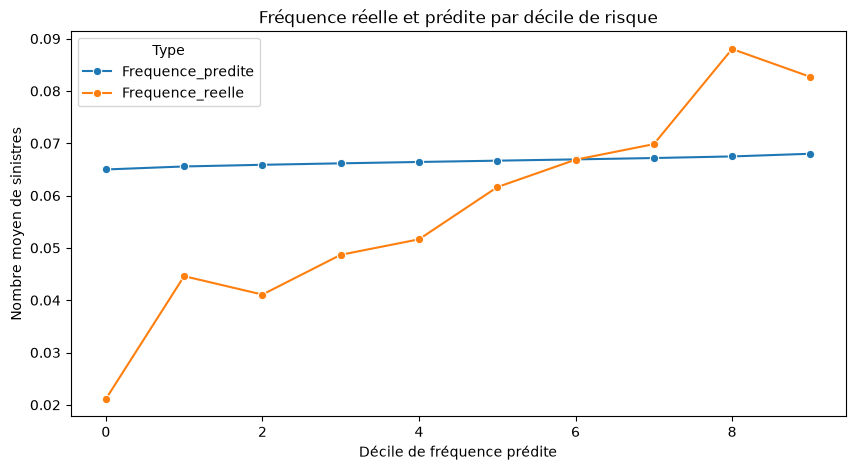

In [37]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=frequency_decile_plot,
    x="Decile_risque",
    y="Frequence",
    hue="Type",
    marker="o"
)

plt.title(
    "Fréquence réelle et prédite par décile de risque"
)
plt.xlabel(
    "Décile de fréquence prédite"
)
plt.ylabel(
    "Nombre moyen de sinistres"
)
plt.show()

## 2. Modélisation de la sévérité

La sévérité représente le coût moyen d’un sinistre.

Le modèle Gamma est entraîné uniquement sur les observations dont le coût total est strictement positif. Les observations sans paiement ne possèdent pas de sévérité positive à modéliser avec cette distribution.

In [38]:
train_severity_mask = (
    df["year"].isin([1, 2, 3])
    & (df["Total_Claims"] > 0)
)

validation_severity_mask = (
    (df["year"] == 4)
    & (df["Total_Claims"] > 0)
)

test_severity_mask = (
    (df["year"] == 5)
    & (df["Total_Claims"] > 0)
)

In [39]:
X_train_severity = df.loc[
    train_severity_mask,
    feature_columns
].copy()

y_train_severity = df.loc[
    train_severity_mask,
    severity_target
].copy()

In [42]:
X_validation_severity = df.loc[
    validation_severity_mask,
    feature_columns
].copy()

y_validation_severity = df.loc[
    validation_severity_mask,
    severity_target
].copy()

In [40]:
X_test_severity = df.loc[
    test_severity_mask,
    feature_columns
].copy()

y_test_severity = df.loc[
    test_severity_mask,
    severity_target
].copy()

In [43]:
severity_summary = pd.DataFrame({
    "Ensemble": [
        "Entraînement",
        "Validation",
        "Test"
    ],
    "Observations": [
        len(y_train_severity),
        len(y_validation_severity),
        len(y_test_severity)
    ],
    "Severite_moyenne": [
        y_train_severity.mean(),
        y_validation_severity.mean(),
        y_test_severity.mean()
    ],
    "Severite_mediane": [
        y_train_severity.median(),
        y_validation_severity.median(),
        y_test_severity.median()
    ],
    "Severite_maximale": [
        y_train_severity.max(),
        y_validation_severity.max(),
        y_test_severity.max()
    ]
})

severity_summary.round(2)

,Ensemble,Observations,Severite_moyenne,Severite_mediane,Severite_maximale
0,Entraînement,3239,799.96,441.00,36573.57
1,Validation,515,654.18,345.00,6918.86
2,Test,361,636.61,303.93,9009.20


In [44]:
assert (y_train_severity > 0).all()
assert (y_validation_severity > 0).all()
assert (y_test_severity > 0).all()

assert not y_train_severity.isnull().any()
assert not y_validation_severity.isnull().any()
assert not y_test_severity.isnull().any()

print(
    "Toutes les sévérités utilisées sont "
    "strictement positives."
)

Toutes les sévérités utilisées sont strictement positives.


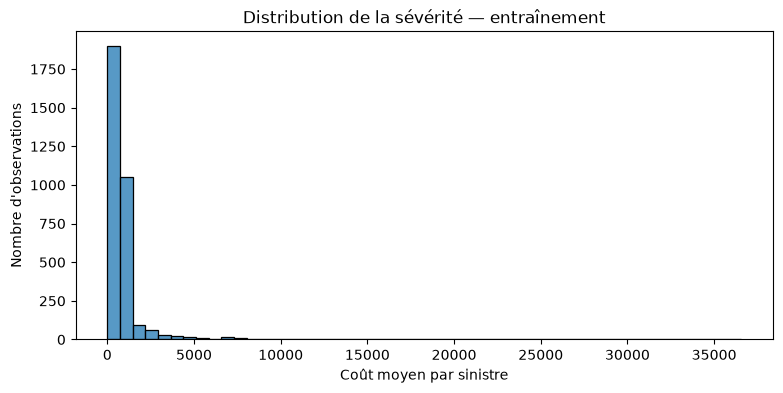

In [45]:
plt.figure(figsize=(9, 4))

sns.histplot(
    y_train_severity,
    bins=50
)

plt.title(
    "Distribution de la sévérité — entraînement"
)
plt.xlabel("Coût moyen par sinistre")
plt.ylabel("Nombre d'observations")
plt.show()

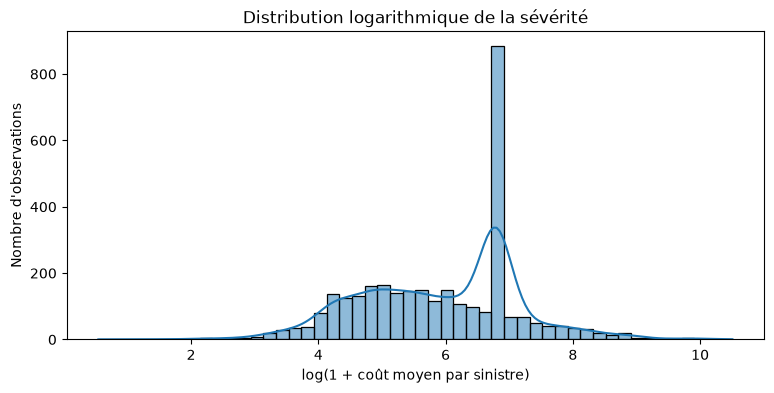

In [46]:
plt.figure(figsize=(9, 4))

sns.histplot(
    np.log1p(y_train_severity),
    bins=50,
    kde=True
)

plt.title(
    "Distribution logarithmique de la sévérité"
)
plt.xlabel(
    "log(1 + coût moyen par sinistre)"
)
plt.ylabel("Nombre d'observations")
plt.show()

In [47]:
def evaluate_severity_model(
    model_name,
    y_true,
    predictions
):
    safe_predictions = np.clip(
        predictions,
        1e-10,
        None
    )

    return {
        "Modele": model_name,
        "MAE": mean_absolute_error(
            y_true,
            predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                predictions
            )
        ),
        "Gamma_deviance": (
            mean_gamma_deviance(
                y_true,
                safe_predictions
            )
        ),
        "Severite_reelle": y_true.mean(),
        "Severite_predite": predictions.mean()
    }

In [48]:
dummy_severity_model = DummyRegressor(
    strategy="mean"
)

In [49]:
dummy_severity_model.fit(
    X_train_severity,
    y_train_severity
)

dummy_severity_predictions = (
    dummy_severity_model.predict(
        X_validation_severity
    )
)

In [50]:
dummy_severity_results = (
    evaluate_severity_model(
        model_name="Dummy sévérité",
        y_true=y_validation_severity,
        predictions=(
            dummy_severity_predictions
        )
    )
)

pd.DataFrame([
    dummy_severity_results
]).round(3)

,Modele,MAE,RMSE,Gamma_deviance,Severite_reelle,Severite_predite
0,Dummy sévérité,603.235,936.616,1.412,654.184,799.965


In [51]:
severity_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [52]:
severity_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [53]:
gamma_model = GammaRegressor(
    alpha=1.0,
    max_iter=1000
)

In [54]:
gamma_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            severity_preprocessor
        ),
        (
            "model",
            gamma_model
        )
    ]
)

In [55]:
gamma_pipeline.fit(
    X_train_severity,
    y_train_severity
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age_client','age_of_car_M','Car_power_M',...,'Policy_PaymentMethodA', 'Policy_PaymentMethodH','appartment']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('binary', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_featu

In [56]:
gamma_validation_predictions = (
    gamma_pipeline.predict(
        X_validation_severity
    )
)

In [57]:
print(
    "Sévérité prédite minimale :",
    gamma_validation_predictions.min()
)

print(
    "Sévérité prédite maximale :",
    gamma_validation_predictions.max()
)

assert (
    gamma_validation_predictions > 0
).all()

print(
    "Toutes les sévérités prédites sont positives."
)

Sévérité prédite minimale : 524.2800427321438
Sévérité prédite maximale : 1353.8993491941355
Toutes les sévérités prédites sont positives.


In [58]:
gamma_results = evaluate_severity_model(
    model_name="Régression Gamma",
    y_true=y_validation_severity,
    predictions=gamma_validation_predictions
)

In [59]:
severity_model_comparison = pd.DataFrame([
    dummy_severity_results,
    gamma_results
])

severity_model_comparison.round(3)

,Modele,MAE,RMSE,Gamma_deviance,Severite_reelle,Severite_predite
0,Dummy sévérité,603.235,936.616,1.412,654.184,799.965
1,Régression Gamma,588.879,925.461,1.379,654.184,779.342


In [60]:
severity_mean_comparison = pd.DataFrame({
    "Type": [
        "Sévérité réelle",
        "Sévérité prédite"
    ],
    "Valeur": [
        y_validation_severity.mean(),
        gamma_validation_predictions.mean()
    ]
})

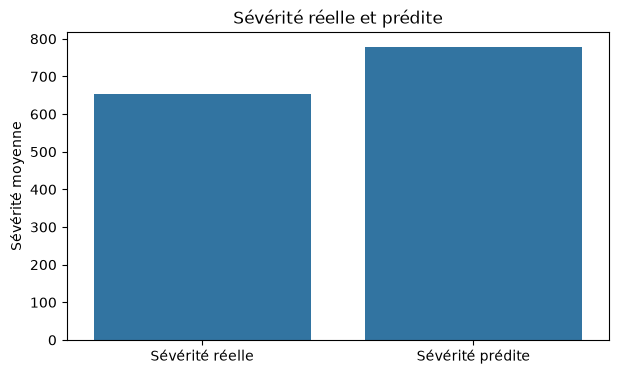

In [61]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=severity_mean_comparison,
    x="Type",
    y="Valeur"
)

plt.title(
    "Sévérité réelle et prédite"
)
plt.xlabel("")
plt.ylabel("Sévérité moyenne")
plt.show()

In [62]:
severity_validation_analysis = pd.DataFrame({
    "Severite_predite": (
        gamma_validation_predictions
    ),
    "Severite_reelle": (
        y_validation_severity.to_numpy()
    )
})

In [63]:
severity_validation_analysis[
    "Decile_risque"
] = pd.qcut(
    severity_validation_analysis[
        "Severite_predite"
    ],
    q=10,
    labels=False,
    duplicates="drop"
)

In [64]:
severity_by_decile = (
    severity_validation_analysis
    .groupby("Decile_risque")
    .agg(
        Nombre_observations=(
            "Severite_reelle",
            "size"
        ),
        Severite_predite=(
            "Severite_predite",
            "mean"
        ),
        Severite_reelle=(
            "Severite_reelle",
            "mean"
        )
    )
)

severity_by_decile.round(2)

,Nombre_observations,Severite_predite,Severite_reelle
Decile_risque,,,
0,52,605.85,681.47
1,51,668.89,446.12
2,52,698.54,501.69
3,51,727.25,588.17
4,52,752.74,728.07
5,51,777.68,472.73
6,51,808.76,644.39
7,52,845.59,739.38
8,51,892.86,848.77


In [65]:
severity_decile_plot = (
    severity_by_decile
    .reset_index()
    .melt(
        id_vars="Decile_risque",
        value_vars=[
            "Severite_predite",
            "Severite_reelle"
        ],
        var_name="Type",
        value_name="Severite"
    )
)

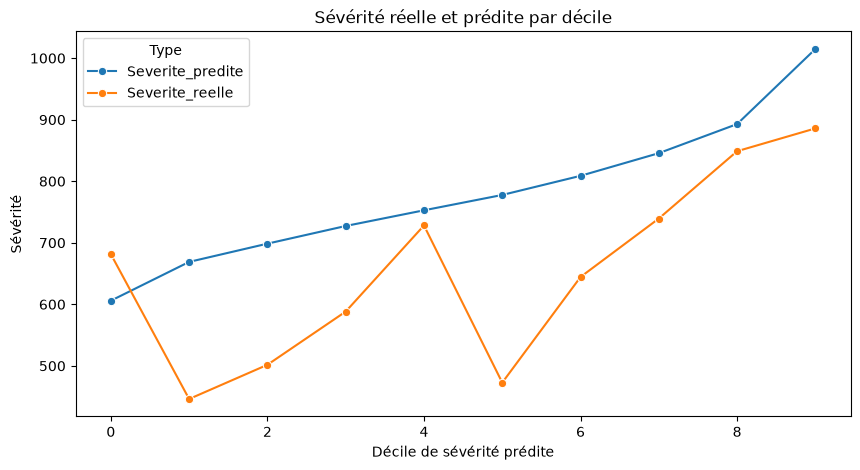

In [66]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=severity_decile_plot,
    x="Decile_risque",
    y="Severite",
    hue="Type",
    marker="o"
)

plt.title(
    "Sévérité réelle et prédite par décile"
)
plt.xlabel(
    "Décile de sévérité prédite"
)
plt.ylabel("Sévérité")
plt.show()

### Limite concernant les sinistres à coût nul

Le modèle Gamma est entraîné uniquement sur les sinistres produisant un paiement positif.

Certains sinistres déclarés possèdent un coût nul. Ils ne peuvent pas être directement inclus dans une régression Gamma, qui exige une cible strictement positive.

Le produit fréquence–sévérité constituera donc un score de coût attendu, mais sa calibration devra être vérifiée sur l’ensemble des observations. Un modèle Tweedie du coût total sera également étudié comme comparaison, car il accepte simultanément les zéros et les montants positifs.

In [67]:
X_validation_all = df.loc[
    validation_mask,
    feature_columns
].copy()

y_validation_total_cost = df.loc[
    validation_mask,
    total_cost_target
].copy()

In [68]:
severity_predictions_all_validation = (
    gamma_pipeline.predict(
        X_validation_all
    )
)

In [69]:
assert (
    len(severity_predictions_all_validation)
    == len(poisson_validation_predictions)
    == len(y_validation_total_cost)
)

print(
    "Les prédictions de fréquence et de "
    "sévérité ont les mêmes dimensions."
)

Les prédictions de fréquence et de sévérité ont les mêmes dimensions.


In [70]:
frequency_severity_predictions = (
    poisson_validation_predictions
    * severity_predictions_all_validation
)

In [71]:
print(
    "Coût attendu minimal :",
    frequency_severity_predictions.min()
)

print(
    "Coût attendu maximal :",
    frequency_severity_predictions.max()
)

print(
    "Coût réel moyen :",
    y_validation_total_cost.mean()
)

print(
    "Coût prédit moyen :",
    frequency_severity_predictions.mean()
)

Coût attendu minimal : 26.76051108541079
Coût attendu maximal : 157.34294606100656
Coût réel moyen : 26.308957404365174
Coût prédit moyen : 52.17096655789699


In [72]:
assert (
    frequency_severity_predictions > 0
).all()

print("Tous les coûts attendus sont positifs.")

Tous les coûts attendus sont positifs.


In [74]:
def evaluate_total_cost_model(
    model_name,
    y_true,
    predictions,
    tweedie_power=1.5
):
    safe_predictions = np.clip(
        predictions,
        1e-10,
        None
    )

    real_total = y_true.sum()
    predicted_total = predictions.sum()

    return {
        "Modele": model_name,
        "MAE": mean_absolute_error(
            y_true,
            predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                predictions
            )
        ),
        "Tweedie_deviance": (
            mean_tweedie_deviance(
                y_true,
                safe_predictions,
                power=tweedie_power
            )
        ),
        "Cout_moyen_reel": y_true.mean(),
        "Cout_moyen_predit": predictions.mean(),
        "Cout_total_reel": real_total,
        "Cout_total_predit": predicted_total,
        "Erreur_totale_pct": (
            (predicted_total - real_total)
            / real_total
            * 100
        )
    }

In [75]:
frequency_severity_results = (
    evaluate_total_cost_model(
        model_name="Fréquence × Sévérité",
        y_true=y_validation_total_cost,
        predictions=(
            frequency_severity_predictions
        )
    )
)

pd.DataFrame([
    frequency_severity_results
]).round(3)

,Modele,MAE,RMSE,Tweedie_deviance,Cout_moyen_reel,Cout_moyen_predit,Cout_total_reel,Cout_total_predit,Erreur_totale_pct
0,Fréquence × Sévérité,75.364,327.068,37.517,26.309,52.171,448409.87,889201.954,98.301


In [76]:
X_train_total_cost = df.loc[
    train_mask,
    feature_columns
].copy()

y_train_total_cost = df.loc[
    train_mask,
    total_cost_target
].copy()

In [77]:
dummy_total_cost_model = DummyRegressor(
    strategy="mean"
)

dummy_total_cost_model.fit(
    X_train_total_cost,
    y_train_total_cost
)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None
Name,Type,Value
"constant_ constant_: ndarray of shape (1, n_outputs)Mean or median or quantile of the training targets or constant valuegiven by the user.","ndarray[float64](1, 1)",[[37.8]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](13,)","['Age_client','age_of_car_M','Car_power_M',...,'Policy_PaymentMethodA', 'Policy_PaymentMethodH','appartment']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,13
n_outputs_ n_outputs_: intNumber of outputs.,int,1


In [78]:
dummy_total_cost_predictions = (
    dummy_total_cost_model.predict(
        X_validation_all
    )
)

In [79]:
dummy_total_cost_results = (
    evaluate_total_cost_model(
        model_name="Dummy coût total",
        y_true=y_validation_total_cost,
        predictions=(
            dummy_total_cost_predictions
        )
    )
)

## 3. Régression Tweedie du coût total

La distribution Tweedie avec une puissance comprise entre 1 et 2 peut représenter une cible comportant :

- une masse importante en zéro ;
- des montants continus strictement positifs ;
- une forte asymétrie.

Elle permet donc de modéliser directement `Total_Claims` sans séparer explicitement fréquence et sévérité.

In [82]:
tweedie_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [84]:
tweedie_model = TweedieRegressor(
    power=1.5,
    alpha=1.0,
    link="log",
    max_iter=1000
)

In [85]:
tweedie_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            tweedie_preprocessor
        ),
        (
            "model",
            tweedie_model
        )
    ]
)

In [86]:
tweedie_pipeline.fit(
    X_train_total_cost,
    y_train_total_cost
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age_client','age_of_car_M','Car_power_M',...,'Policy_PaymentMethodA', 'Policy_PaymentMethodH','appartment']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('binary', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_featu

In [87]:
tweedie_validation_predictions = (
    tweedie_pipeline.predict(
        X_validation_all
    )
)

In [88]:
assert (
    tweedie_validation_predictions > 0
).all()

print(
    "Coût Tweedie minimal :",
    tweedie_validation_predictions.min()
)

print(
    "Coût Tweedie maximal :",
    tweedie_validation_predictions.max()
)

Coût Tweedie minimal : 9.223344838745945
Coût Tweedie maximal : 151.65613238492767


In [89]:
tweedie_results = evaluate_total_cost_model(
    model_name="Régression Tweedie",
    y_true=y_validation_total_cost,
    predictions=tweedie_validation_predictions
)

In [90]:
tweedie_results = evaluate_total_cost_model(
    model_name="Régression Tweedie",
    y_true=y_validation_total_cost,
    predictions=tweedie_validation_predictions
)

In [91]:
cost_candidate_deviances = {
    "Fréquence × Sévérité": (
        frequency_severity_results[
            "Tweedie_deviance"
        ]
    ),
    "Régression Tweedie": (
        tweedie_results[
            "Tweedie_deviance"
        ]
    )
}

In [92]:
selected_cost_model_name = min(
    cost_candidate_deviances,
    key=cost_candidate_deviances.get
)

print(
    f"Approche sélectionnée sur validation : "
    f"{selected_cost_model_name}"
)

Approche sélectionnée sur validation : Régression Tweedie


In [93]:
if (
    selected_cost_model_name
    == "Fréquence × Sévérité"
):
    selected_cost_predictions = (
        frequency_severity_predictions
    )
else:
    selected_cost_predictions = (
        tweedie_validation_predictions
    )

In [94]:
cost_validation_analysis = pd.DataFrame({
    "Cout_reel": (
        y_validation_total_cost.to_numpy()
    ),
    "Cout_predit": (
        selected_cost_predictions
    )
})

In [95]:
cost_validation_analysis[
    "Decile_risque"
] = pd.qcut(
    cost_validation_analysis[
        "Cout_predit"
    ],
    q=10,
    labels=False,
    duplicates="drop"
)

In [96]:
cost_by_decile = (
    cost_validation_analysis
    .groupby("Decile_risque")
    .agg(
        Nombre_observations=(
            "Cout_reel",
            "size"
        ),
        Cout_moyen_reel=(
            "Cout_reel",
            "mean"
        ),
        Cout_moyen_predit=(
            "Cout_predit",
            "mean"
        ),
        Cout_total_reel=(
            "Cout_reel",
            "sum"
        )
    )
)

cost_by_decile.round(2)

,Nombre_observations,Cout_moyen_reel,Cout_moyen_predit,Cout_total_reel
Decile_risque,,,,
0,1705,9.65,18.60,16448.27
1,1704,27.51,23.71,46882.97
2,1704,12.45,26.94,21214.39
3,1705,8.97,29.90,15298.42
4,1704,27.24,32.85,46412.66
5,1704,24.86,35.92,42368.79
6,1705,26.86,39.31,45802.87
7,1704,34.32,43.27,58481.12
8,1704,43.76,48.42,74562.91


In [97]:
cost_decile_plot = (
    cost_by_decile
    .reset_index()
    .melt(
        id_vars="Decile_risque",
        value_vars=[
            "Cout_moyen_reel",
            "Cout_moyen_predit"
        ],
        var_name="Type",
        value_name="Cout_moyen"
    )
)

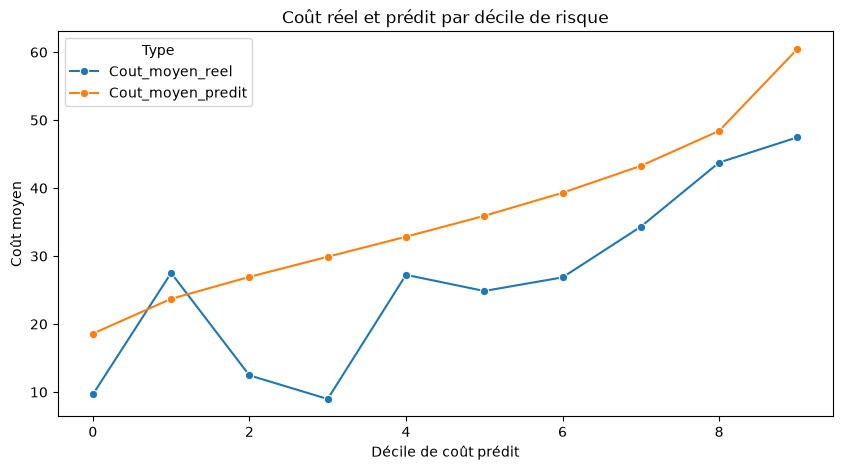

In [98]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=cost_decile_plot,
    x="Decile_risque",
    y="Cout_moyen",
    hue="Type",
    marker="o"
)

plt.title(
    "Coût réel et prédit par décile de risque"
)
plt.xlabel("Décile de coût prédit")
plt.ylabel("Coût moyen")
plt.show()

In [99]:
highest_decile = (
    cost_validation_analysis[
        "Decile_risque"
    ].max()
)

highest_decile_data = (
    cost_validation_analysis[
        cost_validation_analysis[
            "Decile_risque"
        ] == highest_decile
    ]
)

In [100]:
portfolio_average_cost = (
    cost_validation_analysis[
        "Cout_reel"
    ].mean()
)

highest_decile_average_cost = (
    highest_decile_data[
        "Cout_reel"
    ].mean()
)

top_decile_lift = (
    highest_decile_average_cost
    / portfolio_average_cost
)

print(
    "Lift du décile de risque supérieur : "
    f"{top_decile_lift:.2f}"
)

Lift du décile de risque supérieur : 1.80


In [101]:
train_validation_mask = (
    df["year"].isin([1, 2, 3, 4])
)

test_final_mask = (
    df["year"] == 5
)

In [102]:
X_train_validation_all = df.loc[
    train_validation_mask,
    feature_columns
].copy()

X_test_all = df.loc[
    test_final_mask,
    feature_columns
].copy()

y_test_total_cost = df.loc[
    test_final_mask,
    total_cost_target
].copy()

In [103]:
print(
    "Entraînement final :",
    len(X_train_validation_all)
)

print(
    "Test final :",
    len(X_test_all)
)

Entraînement final : 109651
Test final : 13284


In [104]:
final_frequency_pipeline = clone(
    poisson_pipeline
)

In [105]:
y_train_validation_frequency = df.loc[
    train_validation_mask,
    frequency_target
].copy()

In [106]:
final_frequency_pipeline.fit(
    X_train_validation_all,
    y_train_validation_frequency
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age_client','age_of_car_M','Car_power_M',...,'Policy_PaymentMethodA', 'Policy_PaymentMethodH','appartment']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('binary', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_featu

In [107]:
final_frequency_predictions = (
    final_frequency_pipeline.predict(
        X_test_all
    )
)

In [108]:
train_validation_severity_mask = (
    df["year"].isin([1, 2, 3, 4])
    & (df["Total_Claims"] > 0)
)

In [109]:
X_train_validation_severity = df.loc[
    train_validation_severity_mask,
    feature_columns
].copy()

y_train_validation_severity = df.loc[
    train_validation_severity_mask,
    severity_target
].copy()

In [110]:
final_severity_pipeline = clone(
    gamma_pipeline
)

In [111]:
final_severity_pipeline.fit(
    X_train_validation_severity,
    y_train_validation_severity
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age_client','age_of_car_M','Car_power_M',...,'Policy_PaymentMethodA', 'Policy_PaymentMethodH','appartment']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('binary', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_featu

In [112]:
final_severity_predictions = (
    final_severity_pipeline.predict(
        X_test_all
    )
)

In [113]:
final_frequency_severity_cost = (
    final_frequency_predictions
    * final_severity_predictions
)

In [114]:
y_train_validation_total_cost = df.loc[
    train_validation_mask,
    total_cost_target
].copy()

In [115]:
final_tweedie_pipeline = clone(
    tweedie_pipeline
)

In [116]:
final_tweedie_pipeline.fit(
    X_train_validation_all,
    y_train_validation_total_cost
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age_client','age_of_car_M','Car_power_M',...,'Policy_PaymentMethodA', 'Policy_PaymentMethodH','appartment']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('binary', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_featu

In [119]:
final_tweedie_predictions = (
    final_tweedie_pipeline.predict(
        X_test_all
    )
)

In [117]:
final_frequency_severity_results = (
    evaluate_total_cost_model(
        model_name="Fréquence × Sévérité",
        y_true=y_test_total_cost,
        predictions=(
            final_frequency_severity_cost
        )
    )
)

In [120]:
final_tweedie_results = (
    evaluate_total_cost_model(
        model_name="Régression Tweedie",
        y_true=y_test_total_cost,
        predictions=(
            final_tweedie_predictions
        )
    )
)

In [121]:
final_tweedie_results = (
    evaluate_total_cost_model(
        model_name="Régression Tweedie",
        y_true=y_test_total_cost,
        predictions=(
            final_tweedie_predictions
        )
    )
)

In [122]:
final_cost_test_comparison = pd.DataFrame([
    final_frequency_severity_results,
    final_tweedie_results
])

final_cost_test_comparison.round(3)

,Modele,MAE,RMSE,Tweedie_deviance,Cout_moyen_reel,Cout_moyen_predit,Cout_total_reel,Cout_total_predit,Erreur_totale_pct
0,Fréquence × Sévérité,67.544,240.633,34.785,20.601,49.606,273669.78,658960.988,140.787
1,Régression Tweedie,52.540,239.194,31.984,20.601,33.861,273669.78,449808.647,64.362


In [123]:
if (
    selected_cost_model_name
    == "Fréquence × Sévérité"
):
    final_expected_cost = (
        final_frequency_severity_cost
    )
else:
    final_expected_cost = (
        final_tweedie_predictions
    )

In [124]:
assert len(final_expected_cost) == len(
    y_test_total_cost
)

assert (final_expected_cost > 0).all()

print(
    "Les coûts attendus finaux sont valides."
)

Les coûts attendus finaux sont valides.


In [126]:
classification_model_path = Path(
    "../models/classification_pipeline.joblib"
)

classification_metadata_path = Path(
    "../models/classification_metadata.json"
)

In [127]:
classification_pipeline = joblib.load(
    classification_model_path
)

In [128]:
with open(
    classification_metadata_path,
    "r",
    encoding="utf-8"
) as metadata_file:
    classification_metadata = json.load(
        metadata_file
    )

In [129]:
classification_threshold = (
    classification_metadata["threshold"]
)

In [130]:
final_claim_probabilities = (
    classification_pipeline
    .predict_proba(
        X_test_all
    )[:, 1]
)

In [131]:
assert (
    (final_claim_probabilities >= 0)
    & (final_claim_probabilities <= 1)
).all()

print(
    "Les probabilités finales sont valides."
)

Les probabilités finales sont valides.


In [132]:
risk_scores_year5 = df.loc[
    test_final_mask,
    [
        "PolID",
        "year",
        "Has_Claim",
        "Total_NClaims",
        "Total_Claims"
    ]
].copy()

In [133]:
risk_scores_year5[
    "Predicted_Claim_Probability"
] = final_claim_probabilities

risk_scores_year5[
    "Predicted_Frequency"
] = final_frequency_predictions

risk_scores_year5[
    "Predicted_Severity"
] = final_severity_predictions

risk_scores_year5[
    "Predicted_Expected_Cost"
] = final_expected_cost

In [134]:
risk_scores_year5.head()

,PolID,year,Has_Claim,Total_NClaims,Total_Claims,Predicted_Claim_Probability,Predicted_Frequency,Predicted_Severity,Predicted_Expected_Cost
109651,1,5,0,0,0.0,0.114341,0.063317,683.572251,18.788704
109652,3,5,0,0,0.0,0.407156,0.063563,720.700223,20.408495
109653,4,5,0,0,0.0,0.481177,0.063467,738.592742,21.789142
109654,11,5,0,0,0.0,0.408063,0.063503,724.827921,20.834280
109655,15,5,0,0,0.0,0.530291,0.064578,803.542110,28.224292


In [135]:
risk_scores_year5[
    "Risk_Decile"
] = pd.qcut(
    risk_scores_year5[
        "Predicted_Expected_Cost"
    ],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

In [136]:
risk_scores_year5[
    "Risk_Level"
] = pd.cut(
    risk_scores_year5[
        "Risk_Decile"
    ],
    bins=[0, 4, 7, 10],
    labels=[
        "Faible",
        "Moyen",
        "Élevé"
    ],
    include_lowest=True
)

In [137]:
risk_level_summary = (
    risk_scores_year5
    .groupby(
        "Risk_Level",
        observed=False
    )
    .agg(
        Nombre_contrats=(
            "PolID",
            "nunique"
        ),
        Probabilite_moyenne=(
            "Predicted_Claim_Probability",
            "mean"
        ),
        Frequence_predite=(
            "Predicted_Frequency",
            "mean"
        ),
        Cout_attendu_moyen=(
            "Predicted_Expected_Cost",
            "mean"
        ),
        Cout_reel_moyen=(
            "Total_Claims",
            "mean"
        )
    )
)

risk_level_summary.round(3)

,Nombre_contrats,Probabilite_moyenne,Frequence_predite,Cout_attendu_moyen,Cout_reel_moyen
Risk_Level,,,,,
Faible,5314,0.357,0.064,23.047,14.924
Moyen,3985,0.422,0.065,33.913,20.333
Élevé,3985,0.451,0.066,48.230,28.440


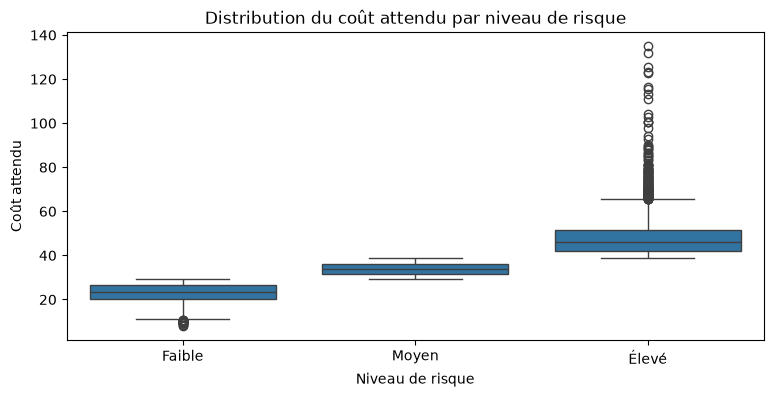

In [138]:
plt.figure(figsize=(9, 4))

sns.boxplot(
    data=risk_scores_year5,
    x="Risk_Level",
    y="Predicted_Expected_Cost",
    order=[
        "Faible",
        "Moyen",
        "Élevé"
    ]
)

plt.title(
    "Distribution du coût attendu par niveau de risque"
)
plt.xlabel("Niveau de risque")
plt.ylabel("Coût attendu")
plt.show()

In [139]:
if (
    selected_cost_model_name
    == "Fréquence × Sévérité"
):
    cost_model_bundle = {
        "approach": (
            "frequency_severity"
        ),
        "frequency_pipeline": (
            final_frequency_pipeline
        ),
        "severity_pipeline": (
            final_severity_pipeline
        )
    }
else:
    cost_model_bundle = {
        "approach": "tweedie",
        "tweedie_pipeline": (
            final_tweedie_pipeline
        )
    }

In [141]:
cost_model_path = (
    model_directory
    / "cost_model_bundle.joblib"
)

joblib.dump(
    cost_model_bundle,
    cost_model_path
)

print(
    f"Modèle de coût enregistré dans : "
    f"{cost_model_path}"
)

Modèle de coût enregistré dans : ..\models\cost_model_bundle.joblib


In [143]:
risk_score_path = Path(
    "../data/processed/risk_scores_year5.csv"
)

risk_scores_year5.to_csv(
    risk_score_path,
    index=False
)

print(
    f"Scores enregistrés dans : "
    f"{risk_score_path}"
)

Scores enregistrés dans : ..\data\processed\risk_scores_year5.csv


In [144]:
risk_scores_check = pd.read_csv(
    risk_score_path
)

assert (
    risk_scores_check.shape
    == risk_scores_year5.shape
)

print(
    "Le fichier des scores a été "
    "enregistré correctement."
)

Le fichier des scores a été enregistré correctement.


## Conclusion

La fréquence des sinistres a été modélisée avec une régression de Poisson et la sévérité avec une régression Gamma.

Une régression Tweedie a également été utilisée pour modéliser directement le coût total, y compris sa masse en zéro.

Le modèle de coût a été sélectionné sur l’année 4 puis évalué une seule fois sur l’année 5.

Un score individuel contenant la probabilité de sinistre, la fréquence prédite, la sévérité prédite et le coût attendu a été produit pour chaque contrat de l’année 5.

Ces scores serviront à évaluer le niveau de risque des futurs groupes collaboratifs, sans utiliser les sinistres réels pour construire les groupes.